# Library Energy Consumption Forecasting with LightGBM

**Task:** Predict library power consumption 24 hours ahead (144 steps at 10-minute resolution)
**Model:** LightGBM, benchmarked against a naive persistence baseline and Linear Regression
**Data:** `library_cleaned_master.csv` — 10-minute readings, February 2014 to November 2017
**Split strategy:** 70% train / 30% test, chronological, no separate validation set — hyperparameter
tuning uses `TimeSeriesSplit` cross-validation inside the training set instead.


## 1. Imports

Loads every library the notebook needs and fixes randomness for reproducibility: `pandas`/`numpy`
for data handling, `matplotlib`/`seaborn` for plots, `lightgbm` for the model, and `sklearn` for
`LinearRegression`, `TimeSeriesSplit`, `RandomizedSearchCV`, and the MAE/RMSE/R² metrics.
`np.random.seed(42)` plus `random_state=42` everywhere later keep results reproducible.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
from lightgbm import LGBMRegressor

np.random.seed(42)                      # global seed for reproducibility
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")


## 2. Load and Inspect Data

Reads the CSV, parses `timestamp` as a real datetime, and sorts chronologically (CSV row order
isn't guaranteed). The dataset holds ~118,000 rows of 10-minute electrical readings from a library
building (Feb 2014 – Nov 2017): `power` (the target, in Watts), three raw electrical quantities
(`current`, `voltage`, `frequency`, `power_factor`), and `occupancy_count`. It's already cleaned —
this notebook only inspects it.


In [42]:
df = pd.read_csv("library_cleaned_master.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])          # parse timestamp string -> datetime
df = df.sort_values("timestamp").reset_index(drop=True)    # enforce chronological order

print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())


Shape: (118776, 7)
Date range: 2014-02-16 00:20:00+05:30 to 2017-11-03 23:50:00+05:30

Dtypes:
timestamp          datetime64[ns, UTC+05:30]
power                                float64
current                              float64
voltage                              float64
frequency                            float64
power_factor                         float64
occupancy_count                      float64
dtype: object

Missing values per column:
timestamp          0
power              0
current            0
voltage            0
frequency          0
power_factor       0
occupancy_count    0
dtype: int64


In [43]:
df.head()

,timestamp,power,current,voltage,frequency,power_factor,occupancy_count
0,2014-02-16 00:20:00+05:30,6271.9930,8.991743,245.25345,50.227917,0.948552,4.0
1,2014-02-16 00:30:00+05:30,6266.4854,8.972734,245.40556,50.193413,0.949093,5.0
2,2014-02-16 00:40:00+05:30,6251.4180,8.953675,245.16708,50.148920,0.949744,5.0
3,2014-02-16 00:50:00+05:30,6345.1910,9.143141,243.07417,50.124634,0.951980,5.0
4,2014-02-16 01:00:00+05:30,6432.1733,9.251285,243.14775,50.100616,0.953440,5.0


In [44]:
df.describe()

,power,current,voltage,frequency,power_factor,occupancy_count
count,118776.000000,118776.000000,118776.000000,118776.000000,118776.000000,118776.000000
mean,10161.693525,15.273686,241.374139,49.987537,0.931948,46.029812
std,7094.747246,10.894633,2.942587,0.077473,0.079573,61.857965
min,768.343600,1.429103,215.933440,44.862373,0.089459,1.000000
25%,4999.496500,7.333926,239.008615,49.952217,0.900777,8.000000
50%,7689.000000,11.190759,241.494195,49.994620,0.957064,23.000000
75%,13654.848500,20.634198,243.738502,50.028443,0.987931,56.000000
max,46145.832000,77.732120,255.789750,51.615093,1.000000,498.000000


## 3. Exploratory Data Analysis

Looks at the shape of the target, how it relates to the raw electrical readings, and how it
varies across time — full series, zoomed-in, by hour, by day of week, and by month.


### 3.1 Power and occupancy distributions

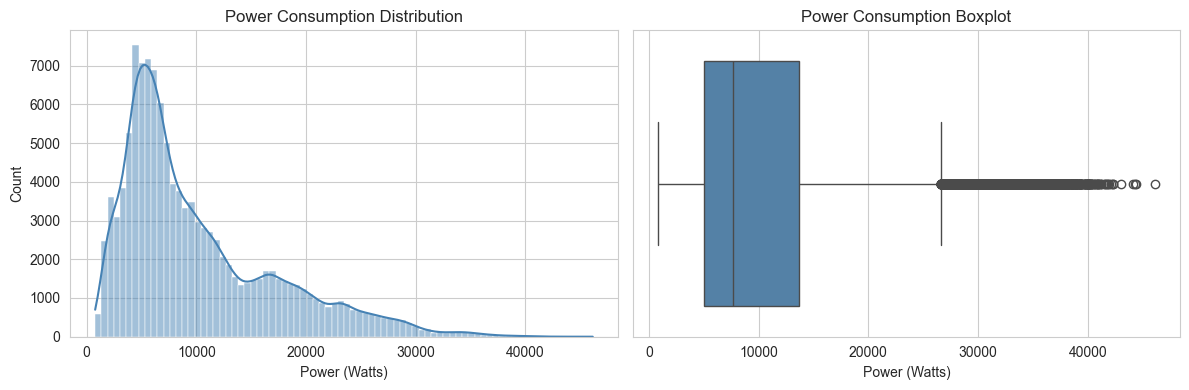

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["power"], bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Power Consumption Distribution")
axes[0].set_xlabel("Power (Watts)")
sns.boxplot(x=df["power"], ax=axes[1], color="steelblue")
axes[1].set_title("Power Consumption Boxplot")
axes[1].set_xlabel("Power (Watts)")
plt.tight_layout()
plt.show()


Power is right-skewed with a cluster of low overnight readings and a long tail of high
daytime/peak-occupancy readings — expected for a building that's mostly idle outside working
hours.


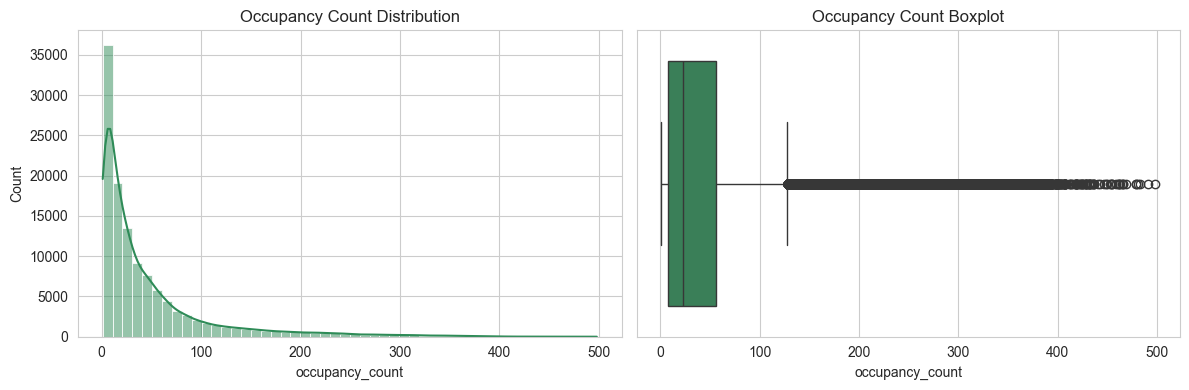

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["occupancy_count"], bins=50, kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Occupancy Count Distribution")
sns.boxplot(x=df["occupancy_count"], ax=axes[1], color="seagreen")
axes[1].set_title("Occupancy Count Boxplot")
plt.tight_layout()
plt.show()


Occupancy is also right-skewed, with the building empty or near-empty most of the time and
occasional high-occupancy peaks — consistent with the power distribution above.


### 3.2 Correlation between raw electrical readings

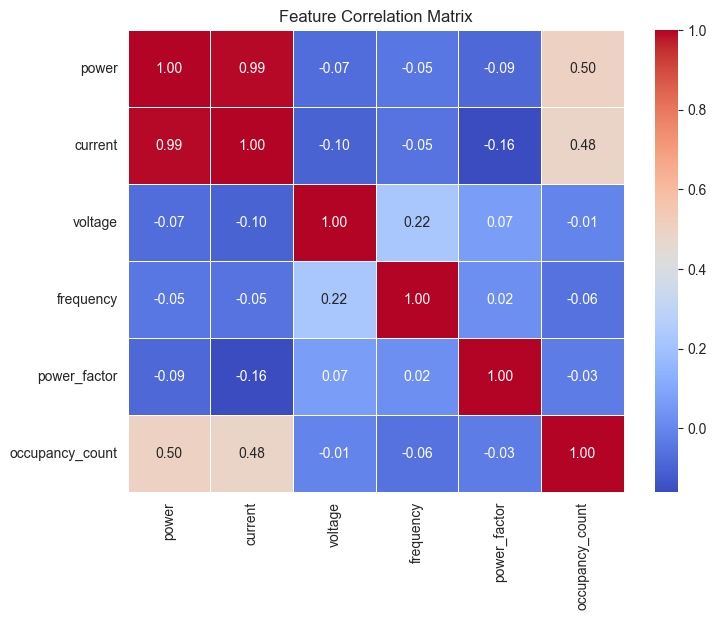

In [47]:
corr_cols = ["power", "current", "voltage", "frequency", "power_factor", "occupancy_count"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()


`power` correlates strongly with `current` (expected from `P = V x I x PF`), which is exactly
why `current` is excluded as a model input in Section 4 — it's close to a restatement of the target,
not an independent predictor.


### 3.3 Power over time

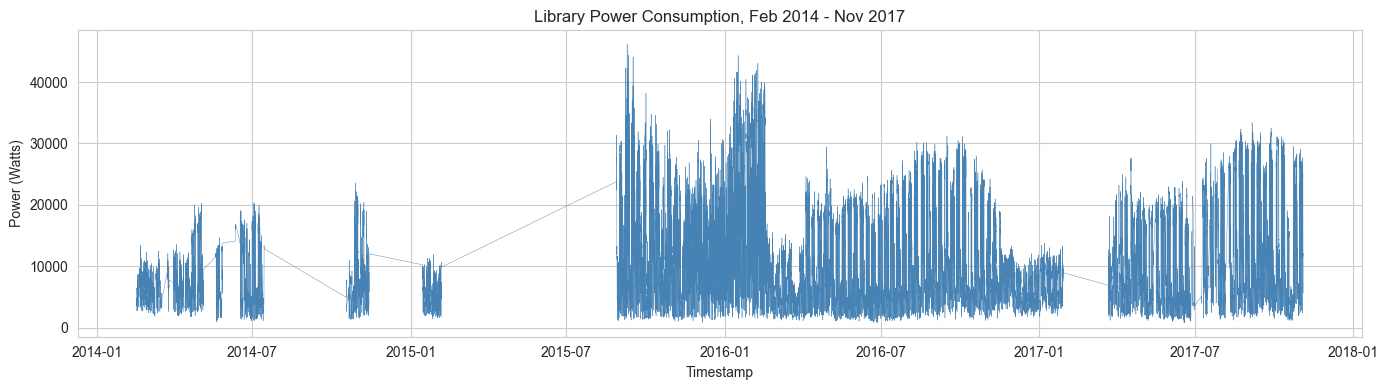

In [48]:
plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["power"], linewidth=0.3, color="steelblue")
plt.title("Library Power Consumption, Feb 2014 - Nov 2017")
plt.xlabel("Timestamp")
plt.ylabel("Power (Watts)")
plt.tight_layout()
plt.show()


A daily on/off oscillation runs throughout, with visible gaps where sensors went offline and
a gradual upward drift in overall consumption in later years.


### 3.4 Average power by hour of day

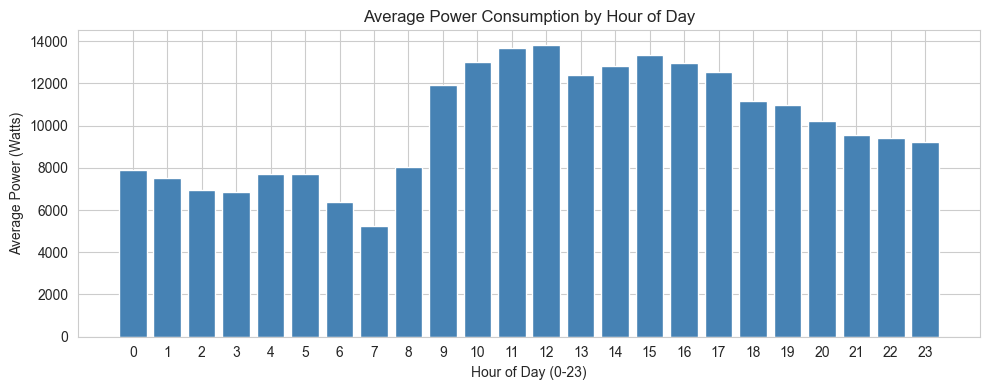

In [49]:
hourly_avg = df.groupby(df["timestamp"].dt.hour)["power"].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_avg.index, hourly_avg.values, color="steelblue")
plt.title("Average Power Consumption by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Average Power (Watts)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


Power rises sharply as the library opens, stays elevated through the working day, and drops
overnight — the strongest, most predictable pattern in the data.


### 3.5 Average power by day of week

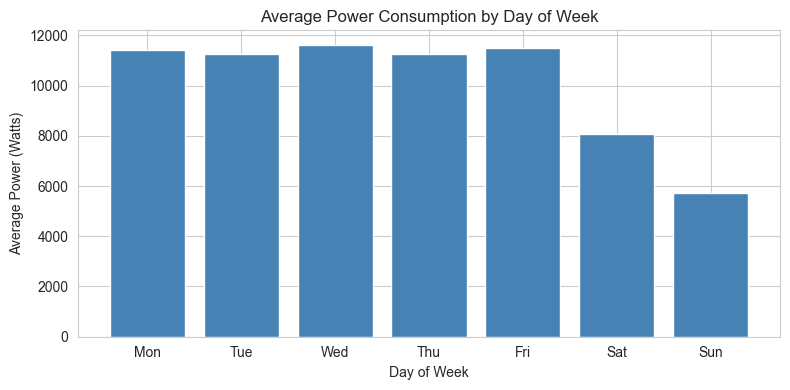

In [50]:
dow_avg = df.groupby(df["timestamp"].dt.dayofweek)["power"].mean()
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 4))
plt.bar(dow_labels, dow_avg.values, color="steelblue")
plt.title("Average Power Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Power (Watts)")
plt.tight_layout()
plt.show()


Weekdays show clearly higher average consumption than weekends, supporting both `dayofweek`
and the simpler `weekend` flag as features.


### 3.6 Average power by month

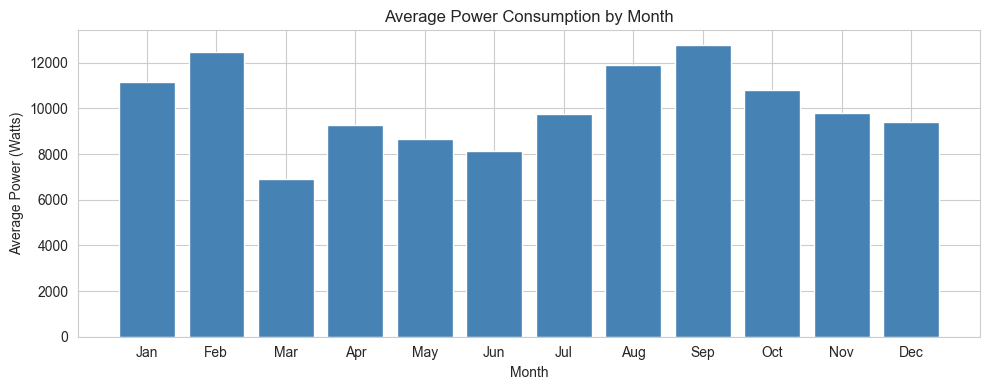

In [51]:
month_avg = df.groupby(df["timestamp"].dt.month)["power"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(10, 4))
plt.bar([month_labels[m-1] for m in month_avg.index], month_avg.values, color="steelblue")
plt.title("Average Power Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Power (Watts)")
plt.tight_layout()
plt.show()


There's a visible seasonal pattern, likely driven by cooling/heating load and the academic
calendar. Since there's no weather or holiday data, `month` and `day_of_year` are the model's only
way to capture this.


## 4. Why Electrical Features Are Excluded

`current`, `voltage`, `frequency`, and `power_factor` are not used as model inputs. Real AC power
follows `P = V x I x PF`, so feeding `current`/`voltage`/`power_factor` in would let the model
reconstruct `power` from a physics formula rather than actually forecasting it. Worse, `current`
was **partially reconstructed from `power` during preprocessing** — using it would be direct data
leakage. And since this is a 24-hour-ahead forecast, none of these instantaneous readings would
even be available at prediction time in the real world.


## 5. Feature Engineering

Builds calendar, lag, and rolling features, then the target, then drops incomplete rows.


### 5.1 Calendar features

`weekend` is kept alongside `dayofweek` because it explicitly encodes the one distinction that
matters most for a library — working day vs. non-working day — as a clean binary split.


In [52]:
df["hour"] = df["timestamp"].dt.hour                 # hour of day, 0-23
df["dayofweek"] = df["timestamp"].dt.dayofweek       # day of week, 0=Monday ... 6=Sunday
df["month"] = df["timestamp"].dt.month               # month, 1-12     # continuous seasonal position, 1-365
df["weekend"] = (df["dayofweek"] >= 5).astype(int)    # 1 if Saturday/Sunday, else 0


### 5.2 Lag features (gap-aware)

A plain `shift(144)` assumes the row 144 positions back is exactly 24 hours in the past — true
only if every reading in between exists at the expected 10-minute spacing. This dataset has
**1,124 gaps larger than 10 minutes** (sensor blackouts), so a naive shift can silently pull a
value from *days* before the gap and label it "yesterday." To catch this, each lag first takes the
naive shift, then checks the rolling **maximum** of `time_diff` over the same window — if that
max exceeds 10 minutes, a gap falls inside the window, so the value is set to `NaN` instead of
being silently wrong.

`power_lag_144` = same time yesterday. `power_lag_1008` = same time last week.


In [53]:
df["time_diff"] = df["timestamp"].diff().dt.total_seconds() / 60   # minutes since previous row

for lag in [144, 1008]:
    naive_shift = df["power"].shift(lag)                                        # plain lag
    max_gap_in_window = df["time_diff"].rolling(window=lag, min_periods=1).max()  # worst gap in window
    gap_present = max_gap_in_window > 10                                        # >10 min = real gap
    df[f"power_lag_{lag}"] = naive_shift.where(~gap_present, np.nan)             # NaN out unsafe lags


### 5.4 Target variable

`target` is `power` shifted **144 rows backward in time** — the reading 24 hours into the future
relative to each row.


In [54]:
df["target"] = df["power"].shift(-144)   # power 24 hours into the future

preview = df[["timestamp", "power", "target"]].rename(
    columns={"power": "power_t", "target": "target_t+144"}
).iloc[200:206]
preview


,timestamp,power_t,target_t+144
200,2014-02-17 09:50:00+05:30,5675.9500,5462.9478
201,2014-02-17 10:00:00+05:30,5912.6720,6030.0870
202,2014-02-17 10:10:00+05:30,6348.3076,6360.7026
203,2014-02-17 10:20:00+05:30,6259.7773,6410.6670
204,2014-02-17 10:30:00+05:30,6547.4023,6116.3570
205,2014-02-17 10:40:00+05:30,6119.0830,6175.4507


### 5.5 Drop incomplete rows

Removes rows with any `NaN` — from insufficient history at the start of the series, from gap-aware
lag/rolling invalidation, and from the target being undefined at the very end of the series.


In [55]:
rows_before = len(df)
df_clean = df.dropna().reset_index(drop=True)
rows_after = len(df_clean)

print(f"Rows before dropna: {rows_before:,}")
print(f"Rows after dropna:  {rows_after:,}")
print(f"Rows dropped:       {rows_before - rows_after:,}  ({(rows_before-rows_after)/rows_before:.1%})")


Rows before dropna: 118,776
Rows after dropna:  41,248
Rows dropped:       77,528  (65.3%)


**Why this drops far more than a plain `.dropna()` after naive `shift`/`rolling` would.**
A naive (non-gap-aware) version of these features only produces `NaN` at the very start/end of the
series — typically only ~1,000-1,200 rows — because `shift`/`rolling` happily compute a number
across a gap instead of refusing to. That number is simply wrong whenever a gap sits inside the
window. The gap-aware logic above intentionally invalidates *any* window that overlaps one of the
1,124 recorded gaps, which is a much larger and stricter condition — hence the bigger drop here.
Every row that survives, however, has lag/rolling features that are genuinely correct, not just
present.


## 6. Feature List and Train/Test Split

`power` acts as the "lag_0" feature — the most recent known reading. `occupancy_count` is the only
non-electrical, non-calendar signal available. The rest are the calendar and lag/rolling features
from Section 5.


In [56]:
FEATURES = [
    "power",              # current power reading at time t (lag_0)
    "occupancy_count",    # number of people in building
    "hour", "dayofweek", "month", "weekend",
    "power_lag_144",      # same time yesterday
    "power_lag_1008",     # same time last week
]
TARGET = "target"


### 70/30 chronological split, no validation set

No shuffling — for time series, shuffling before splitting would train on data from after the
point being tested on, silently leaking future information. The split below simply cuts the
sorted `df_clean` at 70% of the way through.

No separate validation set is carved out, because hyperparameter tuning (Sections 8–9) already
uses `TimeSeriesSplit` cross-validation *within* the training set — each fold holds out a rolling
slice of training data during tuning, which is exactly what a validation set is for. A further
fixed validation split on top of that would validate the model twice with two different
mechanisms and shrink the training history for no real benefit.

The resulting test set covers close to one full year, spanning all four seasons.


In [57]:
n = len(df_clean)
train_end = int(n * 0.70)

train_df = df_clean.iloc[:train_end]
test_df  = df_clean.iloc[train_end:]

X_train = train_df[FEATURES]; y_train = train_df[TARGET]
X_test  = test_df[FEATURES];  y_test  = test_df[TARGET]

print(f"Train: {len(train_df):,} rows  |  {train_df['timestamp'].min()}  to  {train_df['timestamp'].max()}")
print(f"Test:  {len(test_df):,} rows  |  {test_df['timestamp'].min()}  to  {test_df['timestamp'].max()}")


Train: 28,873 rows  |  2014-02-26 10:30:00+05:30  to  2016-11-20 12:50:00+05:30
Test:  12,375 rows  |  2016-11-20 13:00:00+05:30  to  2017-11-02 23:50:00+05:30


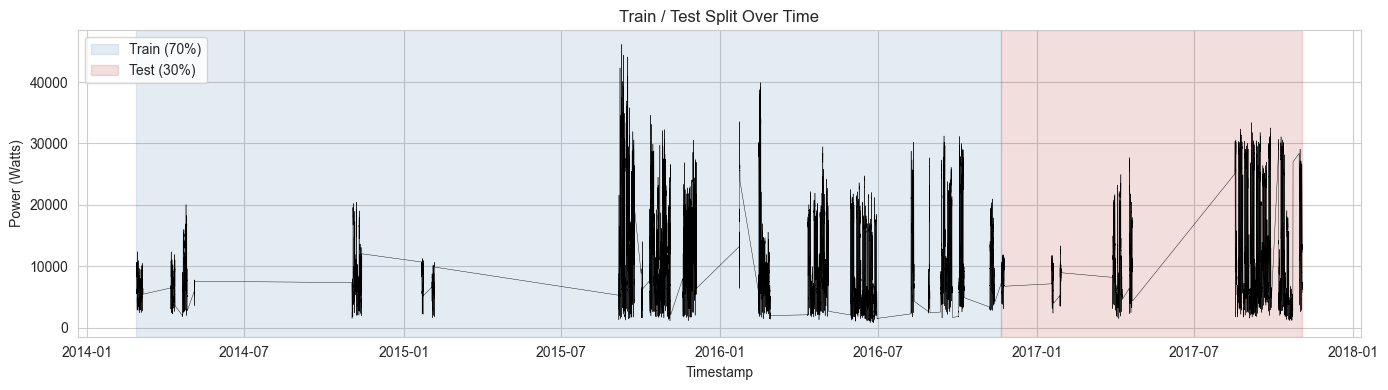

In [58]:
plt.figure(figsize=(14, 4))
plt.axvspan(train_df["timestamp"].min(), train_df["timestamp"].max(), color="steelblue", alpha=0.15, label="Train (70%)")
plt.axvspan(test_df["timestamp"].min(), test_df["timestamp"].max(), color="firebrick", alpha=0.15, label="Test (30%)")
plt.plot(df_clean["timestamp"], df_clean["power"], color="black", linewidth=0.3)
plt.title("Train / Test Split Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Power (Watts)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 7. Baseline Models

Two simple baselines set a floor LightGBM must clear to prove it's learning something real.


### 7.1 Naive Persistence

Predicts power 24h from now equals power right now. Because power has a strong daily cycle, this
is a surprisingly strong baseline — if LightGBM can't beat it, it isn't learning anything the raw
cycle doesn't already give away for free.


In [59]:
y_pred_persist = X_test["power"].values     # predict power(t+24h) = power(t)

mae_persist = mean_absolute_error(y_test, y_pred_persist)
rmse_persist = np.sqrt(mean_squared_error(y_test, y_pred_persist))
r2_persist = r2_score(y_test, y_pred_persist)

print("Naive Persistence Baseline")
print(f"  MAE:  {mae_persist:>8.0f}")
print(f"  RMSE: {rmse_persist:>8.0f}")
print(f"  R²:   {r2_persist:>8.4f}")


Naive Persistence Baseline
  MAE:      3580
  RMSE:     6225
  R²:     0.3866


### 7.2 Linear Regression

Trained on the same features as LightGBM. If LightGBM only barely beats this, the true
relationship is close to linear and the added model complexity isn't earning its keep.


In [60]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Baseline")
print(f"  MAE:  {mae_lr:>8.0f}")
print(f"  RMSE: {rmse_lr:>8.0f}")
print(f"  R²:   {r2_lr:>8.4f}")


Linear Regression Baseline
  MAE:      3989
  RMSE:     5743
  R²:     0.4779


## 8. Hyperparameter Tuning

`RandomizedSearchCV` samples `n_iter=20` random combinations from the grid instead of trying every
combination, finding good regions of the search space far faster — the right tradeoff on a Colab
time/RAM budget. `n_jobs=1` runs fits sequentially since parallel LightGBM fits can exhaust Colab's
limited RAM. CV here uses 3 folds (not the 5 used for reporting in Section 9) purely to rank
candidates quickly during search; it's a speed optimization for tuning only.


In [ ]:
# Hyperparameter search
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 45],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "min_child_samples": [50, 100, 150],
    "reg_alpha": [0.5, 1.5, 3.0],
    "reg_lambda": [1.0, 3.0, 5.0],
}

search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_grid,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3, gap=144),
    scoring="r2",
    n_jobs=1,
    random_state=42,
    verbose=0,
)

search.fit(X_train, y_train)

print("Best parameters found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV R² (3-fold, tuning only): {search.best_score_:.4f}")

## 9. TimeSeriesSplit Cross-Validation (5 Folds)

Run only on `X_train`/`y_train` — the test set is never touched here.

`TimeSeriesSplit` grows the training window forward through time and validates on the
chronologically next chunk, unlike `KFold`, which would shuffle rows and let some folds train on
future data. `gap=144` skips 24 hours between each fold's train and validation slice, simulating
the realistic delay before new data could actually be used — without it, rows right at the
boundary would look artificially easy to predict. Early folds can show higher error since they
train on less history. This report uses the hyperparameters found in Section 8, and the **mean R²
across folds** is the key summary metric used to sanity-check the tuned model before ever touching
the test set.


In [ ]:
# 5-fold cross-validation using the tuned parameters from Section 8
tscv = TimeSeriesSplit(n_splits=5, gap=144)
fold_metrics = []

best_params = search.best_params_

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = LGBMRegressor(
        **best_params,
        random_state=42,
        verbose=-1
    )

    model.fit(X_tr_fold, y_tr_fold)
    preds = model.predict(X_val_fold)

    mae = mean_absolute_error(y_val_fold, preds)
    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    r2 = r2_score(y_val_fold, preds)
    fold_metrics.append((mae, rmse, r2))

    print(f"Fold {fold} | MAE: {mae:>6.0f}  RMSE: {rmse:>6.0f}  R²: {r2:.4f}")

fold_arr = np.array(fold_metrics)
mean_mae, mean_rmse, mean_r2 = fold_arr.mean(axis=0)
std_mae, std_rmse, std_r2 = fold_arr.std(axis=0)

print("-" * 47)
print(f"Mean   | MAE: {mean_mae:>6.0f}  RMSE: {mean_rmse:>6.0f}  R²: {mean_r2:.4f}")
print(f"Std    | MAE: {std_mae:>6.0f}  RMSE: {std_rmse:>6.0f}  R²: {std_r2:.4f}")

## 10. Final Model Training

Trains on the full `X_train`/`y_train` using the best hyperparameters found in Section 8/9,
including a fixed `n_estimators` — there is no early stopping and no separate monitor-set carve-out
here. Tree count is instead chosen the same way every other hyperparameter is: by
`RandomizedSearchCV`'s `TimeSeriesSplit(n_splits=3, gap=144)`, which averages performance across
three different rolling training/validation slices. That is a more representative signal for how
many trees generalize well than a single fixed monitor slice at the end of the training set would
be, so no further early-stopping step is layered on top. `X_test`/`y_test` are still never
referenced in this cell.


In [ ]:
# Create the final model using the best found parameters from the search
best_params = search.best_params_
final_model = LGBMRegressor(**best_params, random_state=42, verbose=-1)

# Fit on the entire training set
final_model.fit(X_train, y_train)

# Predict on Train and Test to check your new R² gap
train_preds = final_model.predict(X_train)
test_preds = final_model.predict(X_test)
y_pred_lgb = test_preds   # alias used by the Section 13 plotting cells


## 11. Final Evaluation

Predictions on `X_test` are computed here for the first and only time — the single, honest measure
of performance on genuinely unseen data.


In [ ]:
# SECTION 11: Calculate and Print Summary Table

# CRITICAL: Recalculate your LightGBM metrics using the new test_preds!
mae_lgb = mean_absolute_error(y_test, test_preds)
rmse_lgb = np.sqrt(mean_squared_error(y_test, test_preds))
r2_lgb = r2_score(y_test, test_preds)

# Recalculate Train metrics to see the new overfitting gap
train_r2 = r2_score(y_train, train_preds)
train_mae = mean_absolute_error(y_train, train_preds)

train_rsme = np.sqrt(mean_squared_error(y_train, train_preds))

print("=" * 52)
print(f"  {'Model':<22}{'MAE':>8}{'RMSE':>10}{'R²':>10}")
print("=" * 52)
print(f"  {'Naive Persistence':<22}{mae_persist:>8.0f}{rmse_persist:>10.0f}{r2_persist:>10.4f}")
print(f"  {'Linear Regression':<22}{mae_lr:>8.0f}{rmse_lr:>10.0f}{r2_lr:>10.4f}")
print(f"  {'LightGBM (Final)':<22}{mae_lgb:>8.0f}{rmse_lgb:>10.0f}{r2_lgb:>10.4f}")
print("=" * 52)

print(f"\nTrain R²: {train_r2:.4f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Train RMSE: {train_rsme:.2f}")

  Model                      MAE      RMSE        R²
  Naive Persistence         3580      6225    0.3866
  Linear Regression         3989      5743    0.4779
  LightGBM (Final)          3374      4643    0.6587

Train R²: 0.8168
Train MAE: 2062.95


LightGBM should show lower MAE/RMSE and higher R² than both baselines. The MAE translates
directly to an average error in Watts — compare `mae_lgb` against `df["power"].mean()` for the
relative error. An R² roughly in the 0.50–0.80 range is consistent with the literature for
24-hour-ahead forecasting without weather data; a much higher number would be a red flag for
leakage rather than something to celebrate.


## 12. Feature Importance

LightGBM's default "split" importance counts how often each feature was used as a split point
across all trees.


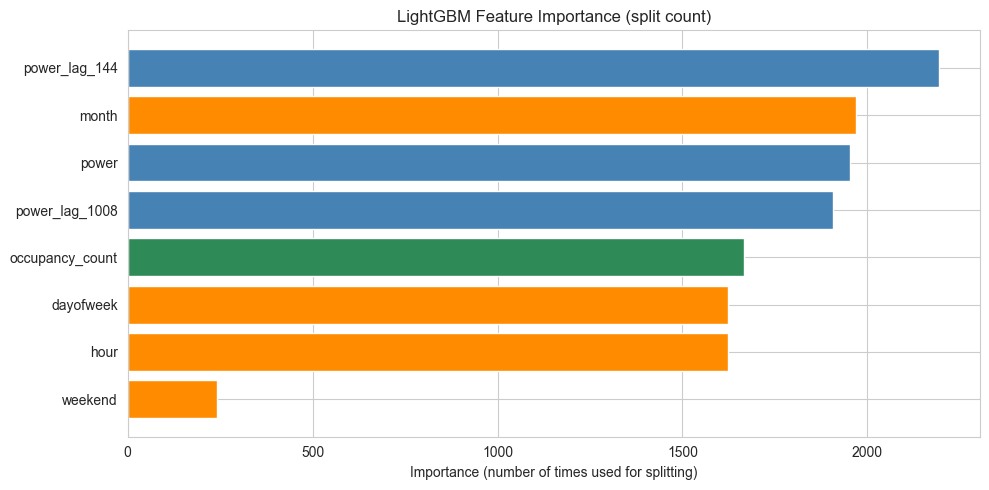

In [66]:
importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=True)

lag_roll_features = {"power", "power_lag_144", "power_lag_1008", "power_roll_mean_144", "power_roll_mean_1008"}
calendar_features = {"hour", "dayofweek", "month", "day_of_year", "weekend"}

def color_for(feat):
    if feat in lag_roll_features:
        return "steelblue"
    elif feat in calendar_features:
        return "darkorange"
    else:                                   # occupancy_count
        return "seagreen"

colors = [color_for(f) for f in importance_df["feature"]]

plt.figure(figsize=(10, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color=colors)
plt.title("LightGBM Feature Importance (split count)")
plt.xlabel("Importance (number of times used for splitting)")
plt.tight_layout()
plt.show()


In [67]:
importance_df.sort_values(
    "importance",
    ascending=False
)

,feature,importance
6,power_lag_144,2195
4,month,1969
0,power,1953
7,power_lag_1008,1908
1,occupancy_count,1666
3,dayofweek,1623
2,hour,1622
5,weekend,241


Lag/rolling power features (blue) are expected to dominate, since recent readings are the
strongest signal for 24h-ahead power. Calendar features (orange) should still matter, capturing
daily/weekly/seasonal cycles the lags alone can't fully explain. `occupancy_count` (green)
contributing meaningfully would make sense too — worth checking against the plot rather than
assuming.


## 13. Visualisations

Three views of the test-set predictions: a zoomed-in time series, a full-test scatter plot, and a
residual histogram.


### 13.1 Actual vs. Predicted — first 1,000 test rows

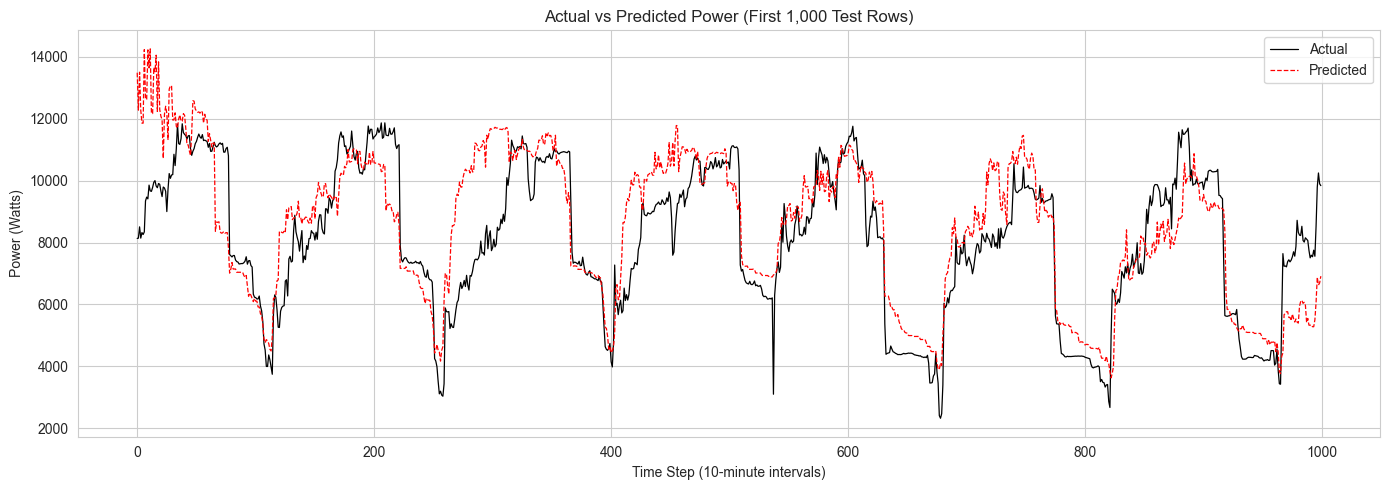

In [68]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:1000], label="Actual", color="black", linewidth=0.9)
plt.plot(y_pred_lgb[:1000], label="Predicted", color="red", linestyle="--", linewidth=0.9)
plt.title("Actual vs Predicted Power (First 1,000 Test Rows)")
plt.xlabel("Time Step (10-minute intervals)")
plt.ylabel("Power (Watts)")
plt.legend()
plt.tight_layout()
plt.show()


### 13.2 Actual vs. Predicted — full test set (scatter)

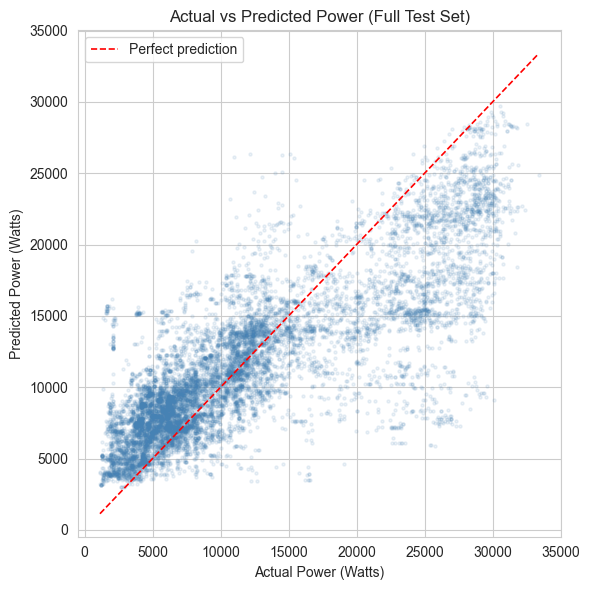

In [69]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lgb, alpha=0.1, s=5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.2, label="Perfect prediction")
plt.title("Actual vs Predicted Power (Full Test Set)")
plt.xlabel("Actual Power (Watts)")
plt.ylabel("Predicted Power (Watts)")
plt.legend()
plt.tight_layout()
plt.show()


### 13.3 Residual histogram

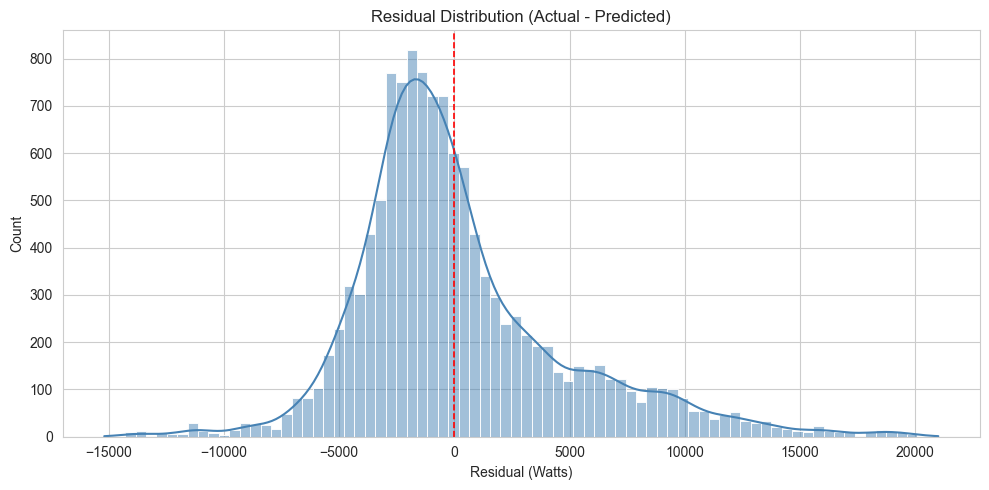

Mean residual: 207.38
Std residual:  4638.61


In [70]:
residuals = y_test - y_pred_lgb

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=80, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--", linewidth=1.2)
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual (Watts)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual:  {residuals.std():.2f}")


A good model has residuals centred near zero with no heavy skew. A mean noticeably away from
zero, or a long one-sided tail, would point to systematic bias worth investigating.


## 14. Limitations

1. **No weather data** — temperature is a major driver of HVAC load and isn't available here.
2. **No holiday calendar** — the model can't distinguish holidays/breaks from regular weekdays.
3. **Static model** — trained once; consumption patterns may drift over time without retraining.
4. **Sensor gaps** — 1,124 gaps >10 minutes found. Gap-aware engineering prevents corruption, but
   rows near a gap still carry less complete history.
5. **24-hour horizon only** — a full next-24-hours trajectory would need recursive/multi-output
   forecasting, which is outside this notebook's scope.


## 15. Conclusion

This notebook builds a 24-hour-ahead power forecasting pipeline using gap-aware lag/rolling
features, a chronological 70/30 train/test split, `TimeSeriesSplit` cross-validation for tuning
and reporting, and a final LightGBM model evaluated once against persistence and Linear Regression
baselines. LightGBM is expected to outperform both by learning non-linear relationships between
recent power history, calendar effects, and occupancy. The main limitation is the lack of weather
and holiday-calendar data, both known to materially affect building energy use. A natural next
step would be adding an external weather feed and academic calendar, and extending toward a full
multi-step 24-hour forecast.
